In [7]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt


In [8]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Helper functions for the normal distribution
def norm_cdf(x): return norm.cdf(x)
def norm_ppf(x): return norm.ppf(x)

# ---------- Monte Carlo Jump Diffusion (Stochastic Jump Size) ----------
def mc_pd_dd_jump_stochastic(V0, B0, sigma, mu, lam, theta, delta, 
                             T=5.0, n_paths=20000, seed=7):
    """
    lam: jump intensity (vector)
    theta: mean of the log-jump size (vector)
    delta: std dev of the log-jump size (vector)
    """
    rng = np.random.default_rng(seed)
    n_obs = len(V0)
    
    # Standard GBM components
    drift = (mu - 0.5 * sigma**2) * T
    volT = sigma * np.sqrt(T)
    
    # 1. Simulate number of jumps for each path (Poisson)
    # Shape: (n_obs, n_paths)
    N = rng.poisson(lam[:, None] * T, size=(n_obs, n_paths))
    
    # 2. Simulate the aggregate jump impact
    # Since the sum of N normal variables N(theta, delta^2) is 
    # itself normal: N(N*theta, N*delta^2)
    aggregate_jump_mean = N * theta[:, None]
    aggregate_jump_std = np.sqrt(N) * delta[:, None]
    
    # Standard normal draws for the jump component
    Z_jump = rng.standard_normal((n_obs, n_paths))
    total_jump_effect = aggregate_jump_mean + aggregate_jump_std * Z_jump
    
    # 3. Simulate diffusion component
    Z_diff = rng.standard_normal((n_obs, n_paths))
    
    # 4. Final Log Asset Value
    logVT = (np.log(V0)[:, None] + drift[:, None] + 
             volT[:, None] * Z_diff + total_jump_effect)

    # Metrics
    PD = (logVT < np.log(B0)[:, None]).mean(axis=1)
    DD = norm_ppf(1 - np.clip(PD, 1e-10, 1 - 1e-10))
    SE = np.sqrt(PD * (1 - PD) / n_paths)
    
    return PD, DD, SE

# ---------- Updated Main Runner ----------
def run_all_models(panel_csv, out_csv,
                   mu_mode="zero",
                   scale_mult=1.5,
                   lambda_const=0.5,
                   n_paths=50000):

    df = pd.read_csv(panel_csv, parse_dates=["date"])

    # Drift calculation
    if mu_mode == "hist":
        df["mu_hist"] = (
            df.groupby("country_clean")["msci_ret_weekly"]
            .transform(lambda x: x.rolling(52, min_periods=10).mean().shift(1)*52)
            .fillna(0)
        )
        mu = df["mu_hist"].values
    else:
        mu = np.zeros(len(df))

    sigma = df["msci_vol_annual"].values
    B0 = df["default_barrier"].values
    V0 = scale_mult * B0
    
    # Extract country-specific jump parameters
    theta = df["theta"].values
    delta = df["delta"].values

    # ----- Model 1: Diffusion (GBM) -----
    # Using existing logic for baseline
    from scipy.stats import norm # Ensure scope
    denom = sigma * np.sqrt(5.0)
    dd_cf = (np.log(V0/B0) + (mu - 0.5*sigma**2)*5.0) / denom
    pd_cf = norm.cdf(-dd_cf)

    # ----- Model 2: Constant Jump Intensity + Stochastic Size -----
    lam_const = np.full(len(df), lambda_const)
    pd_jc, dd_jc, _ = mc_pd_dd_jump_stochastic(V0, B0, sigma, mu, 
                                               lam_const, theta, delta,
                                               n_paths=n_paths, seed=11)

    # ----- Model 3: OVX-driven Jump Intensity + Stochastic Size -----
    lam_ovx = df["OVX"].values / 100
    pd_jo, dd_jo, _ = mc_pd_dd_jump_stochastic(V0, B0, sigma, mu, 
                                               lam_ovx, theta, delta,
                                               n_paths=n_paths, seed=22)

    # Store results
    df["pd_cf_gbm"] = pd_cf
    df["dd_cf_gbm"] = dd_cf
    df["pd_mc_jump_const"] = pd_jc
    df["dd_mc_jump_const"] = dd_jc
    df["pd_mc_jump_ovx"] = pd_jo
    df["dd_mc_jump_ovx"] = dd_jo

    df.to_csv(out_csv, index=False)
    return df

In [9]:
in_path = "data/processed/structural_model_panel_built.csv"
out_path =  "output/mc_gbm_results.csv"


df_res = run_all_models(
        panel_csv=in_path,
        out_csv=out_path,
        mu_mode="zero",
        scale_mult=1.5,
        lambda_const=0.5,
        n_paths=10000)


In [12]:
country = "brazil"   # change here
msci_em = [
    'brazil', 'chile', 'china', 'colombia', 'czech republic', 'czechia',
    'egypt', 'greece', 'hungary', 'india', 'indonesia', 'korea', 'south korea',
    'kuwait', 'malaysia', 'mexico', 'peru', 'philippines', 'poland', 'qatar',
    'saudi arabia', 'south africa', 'taiwan', 'thailand', 'turkey',
    'united arab emirates', 'uae'
]

df_c = df_res[df_res["country"].str.lower() == country.lower()].sort_values("date").copy()


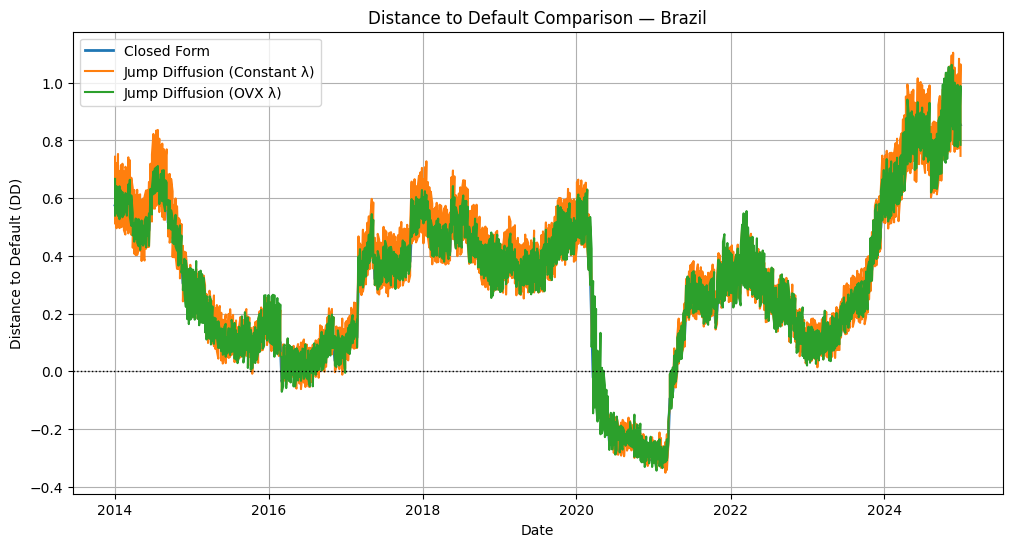

In [13]:
plt.figure(figsize=(12,6))

plt.plot(df_c["date"], df_c["dd_cf_gbm"], label="Closed Form", linewidth=2)
plt.plot(df_c["date"], df_c["dd_mc_jump_const"], label="Jump Diffusion (Constant λ)")
plt.plot(df_c["date"], df_c["dd_mc_jump_ovx"], label="Jump Diffusion (OVX λ)")

plt.axhline(0, color="black", linewidth=1, linestyle=":")
plt.title(f"Distance to Default Comparison — {country.title()}")
plt.ylabel("Distance to Default (DD)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)

plt.show()


In [16]:
from scipy.stats import norm

df_c["pd_gbm"]  = norm.cdf(-df_c["dd_cf_gbm"])
df_c["pd_jc"]   = norm.cdf(-df_c["dd_mc_jump_const"])
df_c["pd_jo"]   = norm.cdf(-df_c["dd_mc_jump_ovx"])


RECOVERY = 0.09
df_c["pd_cds"] = df_c["cds_spread"] / 10000 / (1 - RECOVERY)


import statsmodels.api as sm

def run_reg(x, y):
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
    return model.rsquared, model.params

r2_gbm, b_gbm = run_reg(df_c["pd_gbm"], df_c["pd_cds"])
r2_jc,  b_jc  = run_reg(df_c["pd_jc"],  df_c["pd_cds"])
r2_jo,  b_jo  = run_reg(df_c["pd_jo"],  df_c["pd_cds"])

print("R² Comparison")
print("GBM:        ", r2_gbm)
print("Jump Const: ", r2_jc)
print("Jump OVX:   ", r2_jo)


R² Comparison
GBM:         0.23127406197864042
Jump Const:  0.20893284564736614
Jump OVX:    0.2067246542984138
